In [1]:
# Cell 1: Imports
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# Cell 2: Paths

TRAIN_DIR = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\processed\train"
VAL_DIR   = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\processed\val"
TEST_DIR  = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\processed\test"

In [3]:
# Cell 3: Transforms

train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

In [4]:
from torchvision import datasets

train_data = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)


--- Sample 1 ---
Original Shape: (364, 364, 3)
Tensor Shape: torch.Size([1, 128, 128])
Min: tensor(-1.)
Max: tensor(0.6706)
Tensor Slice:
 tensor([[-1.0000, -0.2627, -0.2549, -0.2549, -0.2471],
        [-1.0000, -0.2627, -0.2549, -0.2627, -0.2471],
        [-1.0000, -0.2549, -0.2549, -0.2549, -0.2000],
        [-1.0000, -0.2392, -0.2549, -0.2235, -0.1608],
        [-1.0000, -0.2627, -0.2627, -0.2157, -0.1686]])

--- Sample 2 ---
Original Shape: (551, 551, 3)
Tensor Shape: torch.Size([1, 128, 128])
Min: tensor(-1.)
Max: tensor(0.7725)
Tensor Slice:
 tensor([[-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.]])

--- Sample 3 ---
Original Shape: (483, 483, 3)
Tensor Shape: torch.Size([1, 128, 128])
Min: tensor(-1.)
Max: tensor(0.6078)
Tensor Slice:
 tensor([[-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1., -1., -1.],
        [-1., -1., -1.,

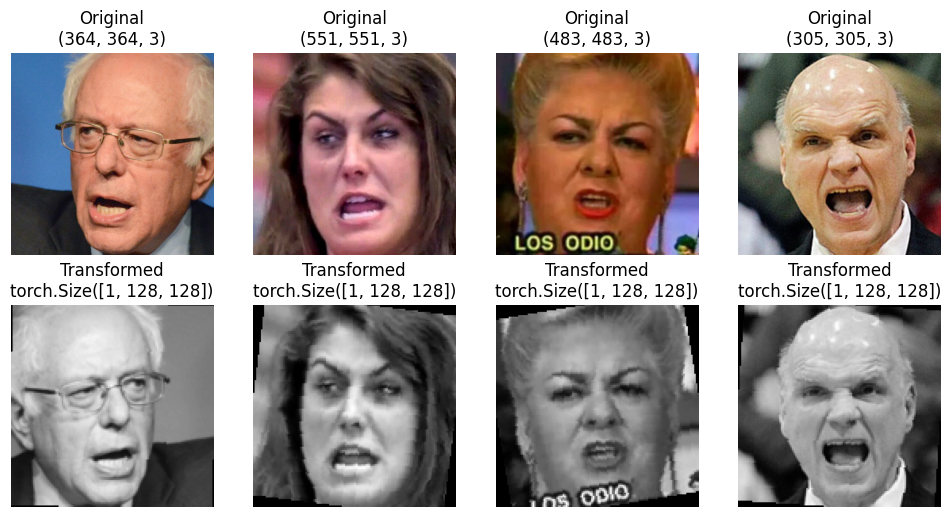

In [5]:
# Cell: Show BEFORE vs AFTER Transform (with tensor output)

import cv2
import numpy as np

def show_transform_effect(dataset, num=4):
    plt.figure(figsize=(12,6))

    for i in range(num):
        # Get original path
        img_path, label = dataset.samples[i]

        # ORIGINAL IMAGE
        original = cv2.imread(img_path)
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

        # TRANSFORMED IMAGE
        transformed, _ = dataset[i]   # tensor
        transformed_img = transformed.squeeze(0).numpy()

        # Plot original
        plt.subplot(2, num, i+1)
        plt.imshow(original_rgb)
        plt.title(f"Original\n{original.shape}")
        plt.axis("off")

        # Plot transformed
        plt.subplot(2, num, i+1+num)
        plt.imshow(transformed_img, cmap='gray')
        plt.title(f"Transformed\n{transformed.shape}")
        plt.axis("off")

        # Print tensor info
        print(f"\n--- Sample {i+1} ---")
        print("Original Shape:", original.shape)
        print("Tensor Shape:", transformed.shape)
        print("Min:", torch.min(transformed))
        print("Max:", torch.max(transformed))
        print("Tensor Slice:\n", transformed[0][:5,:5])

    plt.show()


show_transform_effect(train_data)

In [6]:
# Cell 4: Load Dataset

train_data = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_data   = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_data  = datasets.ImageFolder(TEST_DIR, transform=val_transform)

print("Train Size:", len(train_data))
print("Val Size:", len(val_data))
print("Test Size:", len(test_data))

print("\nClasses:", train_data.classes)

Train Size: 15987
Val Size: 4568
Test Size: 2284

Classes: ['Anger', 'Content', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'SillyFace', 'Surprise']


In [7]:
# Cell 5: DataLoaders

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=64)
test_loader  = DataLoader(test_data, batch_size=64)

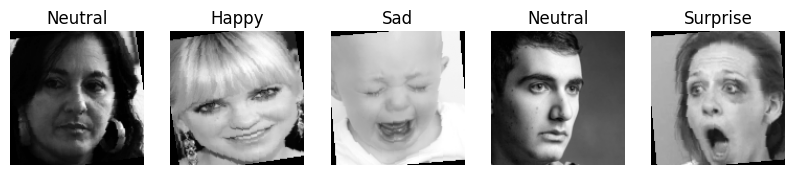

In [8]:
# Cell 6: Visualize Batch with CLASS NAMES

def show_batch(loader, dataset):
    images, labels = next(iter(loader))

    class_names = dataset.classes  # get class names

    plt.figure(figsize=(10,5))
    for i in range(5):
        img = images[i].squeeze(0)

        label_name = class_names[labels[i].item()]  # convert index → name

        plt.subplot(1,5,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(label_name)
        plt.axis("off")

    plt.show()


show_batch(train_loader, train_data)

In [9]:
# Cell 7: Tensor Info (VERY IMPORTANT)

images, labels = next(iter(train_loader))

print("Batch Shape:", images.shape)   # (B, C, H, W)
print("Labels Shape:", labels.shape)

print("\nSample Tensor Stats:")
print("Min:", torch.min(images))
print("Max:", torch.max(images))
print("Mean:", torch.mean(images))

Batch Shape: torch.Size([64, 1, 128, 128])
Labels Shape: torch.Size([64])

Sample Tensor Stats:
Min: tensor(-1.)
Max: tensor(1.)
Mean: tensor(-0.1235)


In [10]:
# Cell 8: Class Mapping (Encoding)

class_to_idx = train_data.class_to_idx

print("Class to Index Mapping:\n")
for k,v in class_to_idx.items():
    print(f"{k} -> {v}")

Class to Index Mapping:

Anger -> 0
Content -> 1
Disgust -> 2
Fear -> 3
Happy -> 4
Neutral -> 5
Sad -> 6
SillyFace -> 7
Surprise -> 8
